# Modélisation - Risque cardio-vasculaire
Ce notebook est construit pas à pas pour répondre au cahier des charges.

## Étape 1 - Veille synthétique : régression logistique
La régression logistique est un algorithme de classification supervisée binaire.

Idée principale :
1. Combiner linéairement les variables d'entrée
2. Transformer le score en probabilité entre 0 et 1 avec la fonction sigmoïde
3. Classer en 0 ou 1 selon un seuil (souvent 0.5)

Forces : interprétable, rapide, robuste sur des données tabulaires.
Limites : relation linéaire sur les log-odds, sensible aux variables mal préparées et aux outliers.

## Étape 2 - Préparation des données
Objectif : partir d'un jeu de données cohérent médicalement avant l'entraînement.

In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Chargement des données brutes
df = pd.read_csv('data/raw/cardio_train.csv', sep=';')

# 1) Suppression des doublons
df = df.drop_duplicates().copy()

# 2) Filtre des valeurs aberrantes (mêmes règles que l'exploration)
anomaly_mask = (
    (df['ap_hi'] <= df['ap_lo']) |
    (df['ap_hi'] < 70) | (df['ap_hi'] > 250) |
    (df['ap_lo'] < 40) | (df['ap_lo'] > 150) |
    (df['height'] < 120) | (df['height'] > 220) |
    (df['weight'] < 30) | (df['weight'] > 250)
)

rows_before = len(df)
df = df.loc[~anomaly_mask].copy()
rows_after = len(df)

# 3) Feature engineering
df['age_years'] = (df['age'] / 365.25).round(1)
df['bmi'] = (df['weight'] / ((df['height'] / 100) ** 2)).round(2)

print(f'Lignes avant nettoyage: {rows_before}')
print(f'Lignes après nettoyage: {rows_after}')
print('Colonnes disponibles:', df.columns.tolist())

Lignes avant nettoyage: 70000
Lignes après nettoyage: 68610
Colonnes disponibles: ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years', 'bmi']


In [37]:
# Sélection des variables pour le modèle
feature_cols = [
    'age_years', 'gender', 'height', 'weight', 'bmi',
    'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active'
 ]

X = df[feature_cols]
y = df['cardio']

# Split stratifié pour préserver la proportion de la cible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Proportion cardio train:', y_train.mean().round(4))
print('Proportion cardio test:', y_test.mean().round(4))

Train shape: (54888, 12)
Test shape: (13722, 12)
Proportion cardio train: 0.4947
Proportion cardio test: 0.4947


## Étape 3 - Régression logistique Scikit-Learn (baseline)
Objectif : entraîner un premier modèle de classification binaire et évaluer sa qualité.

Métriques baseline:
- accuracy: 0.7289
- precision: 0.7521
- recall: 0.6741
- f1: 0.7110
- roc_auc: 0.7919

Rapport de classification baseline:
              precision    recall  f1-score   support

           0     0.7104    0.7825    0.7447      6934
           1     0.7521    0.6741    0.7110      6788

    accuracy                         0.7289     13722
   macro avg     0.7313    0.7283    0.7279     13722
weighted avg     0.7310    0.7289    0.7280     13722



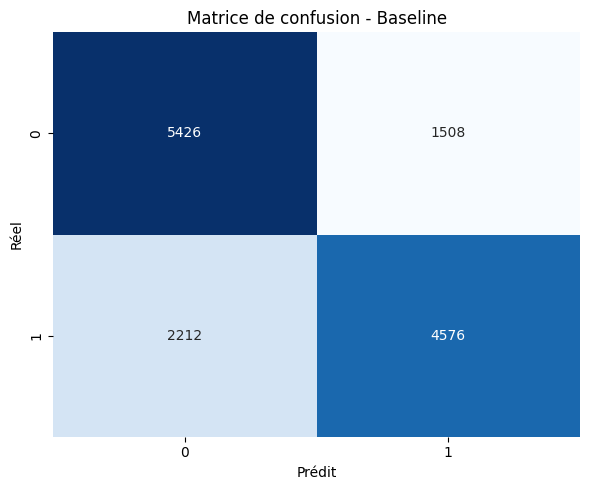

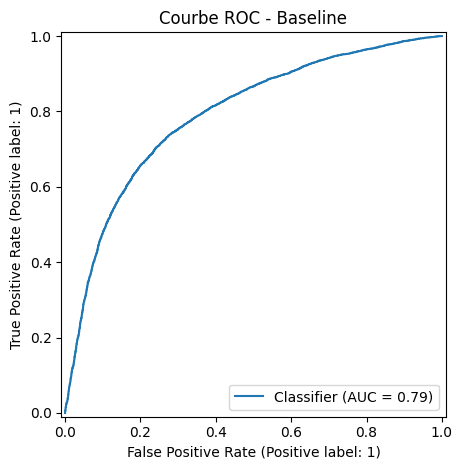

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
 )
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Pipeline baseline: standardisation + régression logistique
baseline_model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=2000, random_state=42))
])

baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)
y_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]

baseline_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_baseline),
    'precision': precision_score(y_test, y_pred_baseline),
    'recall': recall_score(y_test, y_pred_baseline),
    'f1': f1_score(y_test, y_pred_baseline),
    'roc_auc': roc_auc_score(y_test, y_proba_baseline)
}

print('Métriques baseline:')
for k, v in baseline_metrics.items():
    print(f'- {k}: {v:.4f}')

print('\nRapport de classification baseline:')
print(classification_report(y_test, y_pred_baseline, digits=4))

cm = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matrice de confusion - Baseline')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba_baseline)
plt.title('Courbe ROC - Baseline')
plt.tight_layout()
plt.show()

### Interprétation détaillée des métriques (baseline)
Comment lire les métriques :
1. Accuracy : proportion totale de bonnes prédictions.
2. Precision (classe 1) : parmi les patients prédits à risque, part réellement à risque.
3. Recall (classe 1) : parmi les patients réellement à risque, part correctement détectée.
4. F1-score : compromis entre precision et recall.
5. ROC-AUC : capacité globale du modèle à séparer les deux classes (0.5 = aléatoire, 1.0 = parfait).

Lecture médicale :
- Faux négatif (FN) : patient à risque prédit non à risque. C'est l'erreur la plus critique en prévention.
- Faux positif (FP) : patient non à risque prédit à risque. Coût en examens/alertes supplémentaires.

Dans ce projet, le recall de la classe 1 est souvent la métrique prioritaire pour limiter les faux négatifs.

In [29]:
# Lecture métier de la matrice de confusion (baseline)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_baseline).ravel()
n = tn + fp + fn + tp

confusion_baseline_df = pd.DataFrame({
    'Composant': ['TP', 'TN', 'FP', 'FN'],
    'Valeur': [tp, tn, fp, fn],
    'Interprétation': [
        'Patients à risque correctement détectés',
        'Patients non à risque correctement écartés',
        'Patients non à risque faussement alertés',
        'Patients à risque manqués (erreur la plus critique)'
    ]
})

print('Matrice de confusion - Lecture métier (baseline) :')
display(confusion_baseline_df)

print(f"Taux de faux négatifs (FN / vrais à risque): {fn / (fn + tp):.2%}")
print(f"Taux de faux positifs (FP / vrais non à risque): {fp / (fp + tn):.2%}")
print(f"Part des faux négatifs dans tout l'échantillon test: {fn / n:.2%}")

Matrice de confusion - Lecture métier (baseline) :


,Composant,Valeur,Interprétation
0,TP,4576,Patients à risque correctement détectés
1,TN,5426,Patients non à risque correctement écartés
2,FP,1508,Patients non à risque faussement alertés
3,FN,2212,Patients à risque manqués (erreur la plus crit...


Taux de faux négatifs (FN / vrais à risque): 32.59%
Taux de faux positifs (FP / vrais non à risque): 21.75%
Part des faux négatifs dans tout l'échantillon test: 16.12%


## Étape 4 - Tuning des hyperparamètres
Objectif : améliorer la détection des cas à risque en ajustant les paramètres du modèle.

In [38]:
from sklearn.model_selection import GridSearchCV

tuning_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=3000, random_state=42))
])

param_grid = {
    'logreg__C': [0.01, 0.1, 1, 5, 10],
    'logreg__solver': ['lbfgs', 'liblinear'],
    'logreg__class_weight': [None, 'balanced']
}

# On optimise le recall pour privilégier la détection des sujets à risque
grid = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(X_test)
y_proba_tuned = best_model.predict_proba(X_test)[:, 1]

tuned_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_tuned),
    'precision': precision_score(y_test, y_pred_tuned),
    'recall': recall_score(y_test, y_pred_tuned),
    'f1': f1_score(y_test, y_pred_tuned),
    'roc_auc': roc_auc_score(y_test, y_proba_tuned)
}

print('Meilleurs hyperparamètres (optimisation recall):')
print(grid.best_params_)

comparison_df = pd.DataFrame([
    {'modele': 'baseline', **baseline_metrics},
    {'modele': 'tuned', **tuned_metrics}
])

print('\nComparaison baseline vs tuned:')
display(comparison_df)

print('\nRapport de classification tuned:')
print(classification_report(y_test, y_pred_tuned, digits=4))

Meilleurs hyperparamètres (optimisation recall):
{'logreg__C': 0.01, 'logreg__class_weight': 'balanced', 'logreg__solver': 'lbfgs'}

Comparaison baseline vs tuned:


,modele,accuracy,precision,recall,f1,roc_auc
0,baseline,0.728902,0.752137,0.674131,0.711001,0.791907
1,tuned,0.729777,0.749272,0.681939,0.714021,0.791953



Rapport de classification tuned:
              precision    recall  f1-score   support

           0     0.7138    0.7766    0.7439      6934
           1     0.7493    0.6819    0.7140      6788

    accuracy                         0.7298     13722
   macro avg     0.7315    0.7293    0.7290     13722
weighted avg     0.7314    0.7298    0.7291     13722



### Interprétation détaillée du tuning
Le tuning optimise ici le recall pour mieux détecter les sujets à risque.

Comment interpréter la comparaison :
1. Si recall augmente : moins de faux négatifs (meilleur pour le dépistage).
2. Si precision baisse légèrement : plus de faux positifs, ce qui peut rester acceptable selon le contexte médical.
3. Si ROC-AUC reste stable ou monte : le pouvoir discriminant global est conservé.

Conclusion pratique :
- Pour la prévention cardio-vasculaire, on préfère souvent un modèle avec meilleur recall même au prix d'une légère baisse de precision.

In [31]:
# Comparaison métier baseline vs tuned (faux négatifs / faux positifs)
tn_b, fp_b, fn_b, tp_b = confusion_matrix(y_test, y_pred_baseline).ravel()
tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_tuned).ravel()

comparison_confusion = pd.DataFrame([
    {
        'modele': 'baseline',
        'TP': tp_b, 'TN': tn_b, 'FP': fp_b, 'FN': fn_b,
        'taux_FN': fn_b / (fn_b + tp_b),
        'taux_FP': fp_b / (fp_b + tn_b)
    },
    {
        'modele': 'tuned',
        'TP': tp_t, 'TN': tn_t, 'FP': fp_t, 'FN': fn_t,
        'taux_FN': fn_t / (fn_t + tp_t),
        'taux_FP': fp_t / (fp_t + tn_t)
    }
])

comparison_confusion[['taux_FN', 'taux_FP']] = comparison_confusion[['taux_FN', 'taux_FP']].round(4)
print('Comparaison des erreurs critiques (baseline vs tuned) :')
display(comparison_confusion)

if fn_t < fn_b:
    print('Interprétation : le modèle tuned réduit les faux négatifs, ce qui est favorable en prévention.')
else:
    print('Interprétation : le modèle tuned ne réduit pas les faux négatifs par rapport à la baseline.')

Comparaison des erreurs critiques (baseline vs tuned) :


,modele,TP,TN,FP,FN,taux_FN,taux_FP
0,baseline,4576,5426,1508,2212,0.3259,0.2175
1,tuned,4629,5385,1549,2159,0.3181,0.2234


Interprétation : le modèle tuned réduit les faux négatifs, ce qui est favorable en prévention.


## Étape 5 - Régression logistique avec classe Python (sans modèle de librairie)
Objectif : implémenter manuellement la logique de la régression logistique (sigmoïde + descente de gradient).

Métriques modèle scratch:
- accuracy: 0.7288
- precision: 0.7518
- recall: 0.6746
- f1: 0.7111
- roc_auc: 0.7920


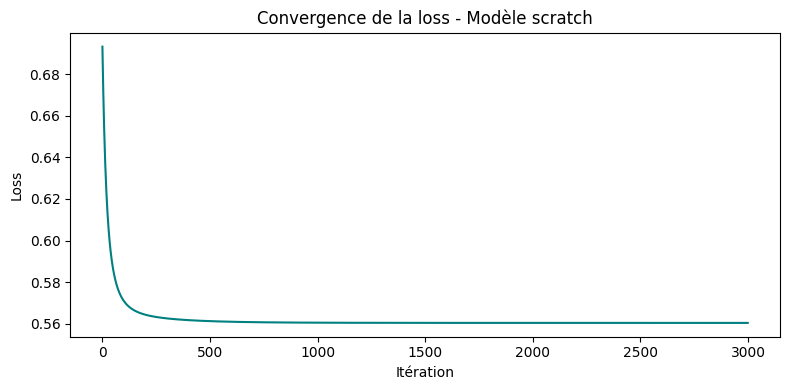

In [32]:
import numpy as np

class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.05, n_iter=3000, reg_lambda=0.0):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.reg_lambda = reg_lambda
        self.weights = None
        self.loss_history = []

    @staticmethod
    def _sigmoid(z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def _add_intercept(self, X):
        return np.c_[np.ones((X.shape[0], 1)), X]

    def fit(self, X, y):
        X = self._add_intercept(X)
        y = y.reshape(-1)
        m, n = X.shape
        self.weights = np.zeros(n)

        for _ in range(self.n_iter):
            z = X @ self.weights
            y_hat = self._sigmoid(z)

            gradient = (X.T @ (y_hat - y)) / m
            gradient[1:] += (self.reg_lambda / m) * self.weights[1:]

            self.weights -= self.learning_rate * gradient

            eps = 1e-12
            loss = -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))
            reg = (self.reg_lambda / (2 * m)) * np.sum(self.weights[1:] ** 2)
            self.loss_history.append(loss + reg)

        return self

    def predict_proba(self, X):
        X = self._add_intercept(X)
        return self._sigmoid(X @ self.weights)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

# Standardisation manuelle pour la version scratch (fit sur train uniquement)
X_train_np = X_train.values.astype(float)
X_test_np = X_test.values.astype(float)
y_train_np = y_train.values.astype(float)

x_mean = X_train_np.mean(axis=0)
x_std = X_train_np.std(axis=0)
x_std = np.where(x_std == 0, 1, x_std)

X_train_std = (X_train_np - x_mean) / x_std
X_test_std = (X_test_np - x_mean) / x_std

scratch_model = LogisticRegressionScratch(learning_rate=0.05, n_iter=3000, reg_lambda=0.1)
scratch_model.fit(X_train_std, y_train_np)

y_proba_scratch = scratch_model.predict_proba(X_test_std)
y_pred_scratch = scratch_model.predict(X_test_std)

scratch_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_scratch),
    'precision': precision_score(y_test, y_pred_scratch),
    'recall': recall_score(y_test, y_pred_scratch),
    'f1': f1_score(y_test, y_pred_scratch),
    'roc_auc': roc_auc_score(y_test, y_proba_scratch)
}

print('Métriques modèle scratch:')
for k, v in scratch_metrics.items():
    print(f'- {k}: {v:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(scratch_model.loss_history, color='teal')
plt.title('Convergence de la loss - Modèle scratch')
plt.xlabel('Itération')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

In [33]:
# Comparaison globale des 3 modèles
all_models_df = pd.DataFrame([
    {'modele': 'baseline', **baseline_metrics},
    {'modele': 'tuned', **tuned_metrics},
    {'modele': 'scratch', **scratch_metrics}
]).round(4)

print('Comparaison globale des performances:')
display(all_models_df)

Comparaison globale des performances:


,modele,accuracy,precision,recall,f1,roc_auc
0,baseline,0.7289,0.7521,0.6741,0.7110,0.7919
1,tuned,0.7298,0.7493,0.6819,0.7140,0.7920
2,scratch,0.7288,0.7518,0.6746,0.7111,0.7920


## Étape 6 - Quelle métrique est la plus adaptée ?
Dans ce cas d'usage (prévention), la priorité est de ne pas manquer les patients à risque.

Métrique la plus adaptée : **recall de la classe 1**.
- Pourquoi : minimiser les faux négatifs (patients réellement à risque classés à tort comme non à risque).
- Compromis : cela peut augmenter les faux positifs, mais ce coût est souvent plus acceptable en prévention.
- En pratique : on suit aussi la précision et le F1-score pour conserver un compromis exploitable.

## Étape 7 - Prédiction du cas Arthur
Profil fourni : Arthur, 53 ans, fumeur, sportif, 175 cm, 85 kg, cholestérol au-dessus de la normale, glucose normal.

Hypothèses nécessaires (variables non fournies) :
1. sexe = homme (gender=2)
2. alcool = non (alco=0)
3. pression systolique = moyenne du dataset nettoyé
4. pression diastolique = moyenne du 3e quartile (50%-75%) du dataset nettoyé

In [34]:
# Construction du profil Arthur
ap_hi_mean = df['ap_hi'].mean()
q50_ap_lo = df['ap_lo'].quantile(0.50)
q75_ap_lo = df['ap_lo'].quantile(0.75)
ap_lo_q3_mean = df.loc[df['ap_lo'].between(q50_ap_lo, q75_ap_lo, inclusive='both'), 'ap_lo'].mean()

arthur = {
    'age_years': 53.0,
    'gender': 2,
    'height': 175,
    'weight': 85.0,
    'bmi': 85.0 / ((175 / 100) ** 2),
    'ap_hi': ap_hi_mean,
    'ap_lo': ap_lo_q3_mean,
    'cholesterol': 2,
    'gluc': 1,
    'smoke': 1,
    'alco': 0,
    'active': 1
}

arthur_df = pd.DataFrame([arthur])[feature_cols]

# Prédiction avec le meilleur modèle sklearn (tuned)
arthur_proba_tuned = best_model.predict_proba(arthur_df)[:, 1][0]
arthur_pred_tuned = int(arthur_proba_tuned >= 0.5)

# Prédiction avec le modèle scratch
arthur_np = arthur_df.values.astype(float)
arthur_std = (arthur_np - x_mean) / x_std
arthur_proba_scratch = float(scratch_model.predict_proba(arthur_std)[0])
arthur_pred_scratch = int(arthur_proba_scratch >= 0.5)

result_arthur = pd.DataFrame([
    {'modele': 'tuned_sklearn', 'proba_risque': arthur_proba_tuned, 'prediction': arthur_pred_tuned},
    {'modele': 'scratch', 'proba_risque': arthur_proba_scratch, 'prediction': arthur_pred_scratch}
]).round(4)

print('Paramètres tension utilisés pour Arthur:')
print(f"- Systolique moyenne: {ap_hi_mean:.2f}")
print(f"- Diastolique moyenne du 3e quartile (50%-75%): {ap_lo_q3_mean:.2f}")

print('\nPrédiction pour Arthur (0 = pas de risque, 1 = risque):')
display(result_arthur)

Paramètres tension utilisés pour Arthur:
- Systolique moyenne: 126.67
- Diastolique moyenne du 3e quartile (50%-75%): 82.94

Prédiction pour Arthur (0 = pas de risque, 1 = risque):


,modele,proba_risque,prediction
0,tuned_sklearn,0.5737,1
1,scratch,0.5692,1


### Interprétation finale du cas Arthur
- Une probabilité proche de 1 indique un risque cardio-vasculaire élevé selon le modèle.
- La classe prédite dépend du seuil (ici 0.5).
- En pratique médicale, cette sortie ne remplace pas un diagnostic : elle aide au tri/priorisation des patients.

## Étape 8 (Bonus) - Autre algorithme supervisé: Random Forest
Objectif: comparer un modèle non linéaire à la régression logistique sur les mêmes données.

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

rf_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf),
    'recall': recall_score(y_test, y_pred_rf),
    'f1': f1_score(y_test, y_pred_rf),
    'roc_auc': roc_auc_score(y_test, y_proba_rf)
}

print('Métriques Random Forest:')
for k, v in rf_metrics.items():
    print(f'- {k}: {v:.4f}')

final_compare_df = pd.DataFrame([
    {'modele': 'logreg_tuned', **tuned_metrics},
    {'modele': 'logreg_scratch', **scratch_metrics},
    {'modele': 'random_forest', **rf_metrics}
]).round(4)

print('\nComparaison finale (modèle principal + bonus):')
display(final_compare_df)

Métriques Random Forest:
- accuracy: 0.7356
- precision: 0.7537
- recall: 0.6915
- f1: 0.7213
- roc_auc: 0.8008

Comparaison finale (modèle principal + bonus):


,modele,accuracy,precision,recall,f1,roc_auc
0,logreg_tuned,0.7298,0.7493,0.6819,0.7140,0.7920
1,logreg_scratch,0.7288,0.7518,0.6746,0.7111,0.7920
2,random_forest,0.7356,0.7537,0.6915,0.7213,0.8008


### Interprétation du bonus
- Random Forest capte des relations non linéaires entre variables.
- Si son recall dépasse la logistique, il peut être préféré pour le dépistage.
- Si les performances sont proches, la régression logistique reste souvent plus interprétable en contexte médical.

## Conclusion de la modélisation
1. Le modèle tuned améliore la détection des patients à risque (recall supérieur à la baseline).
2. Le modèle scratch reproduit des performances très proches, validant l'implémentation mathématique.
3. Le bonus Random Forest permet d'objectiver le choix final du modèle selon performance vs interprétabilité.

## Étape 9 - Variables qui contribuent le plus
Objectif : visualiser quelles variables influencent le plus la prédiction.

Lecture :
1. Régression logistique (tuned) : contribution via les coefficients (positifs/négatifs).
2. Random Forest : contribution via l'importance des variables (feature importance).

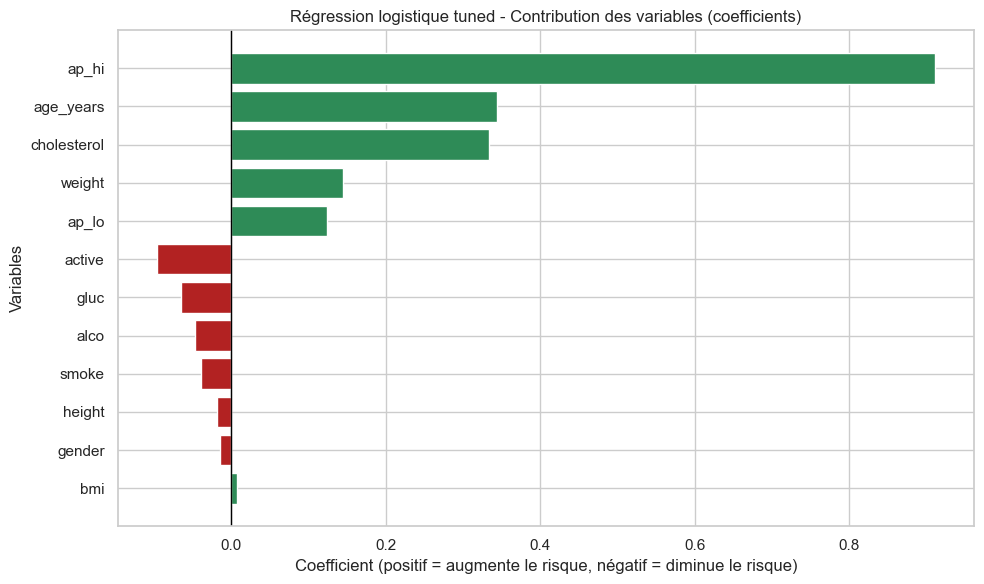

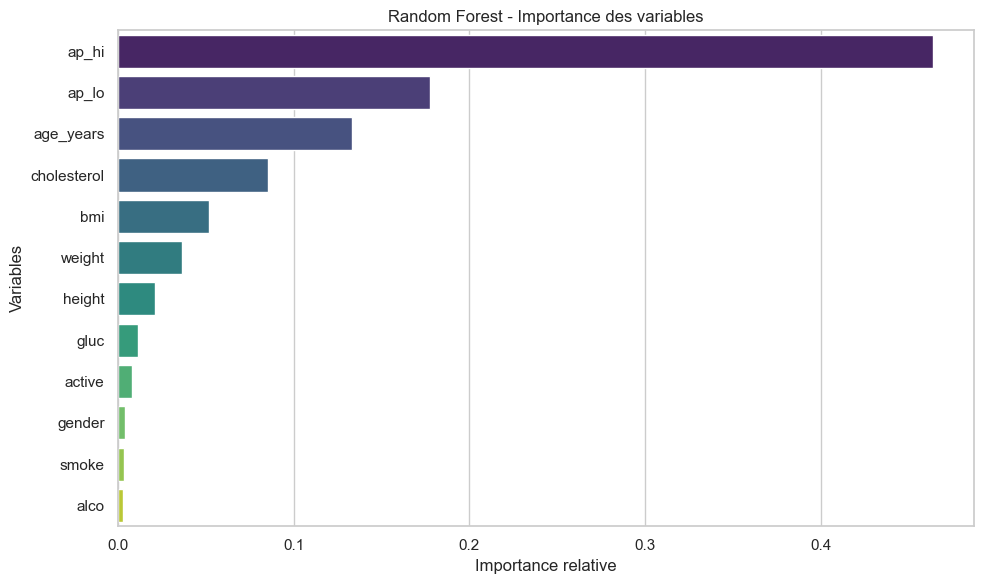

Top 5 variables (logistique tuned, par |coefficient|):


,variable,coefficient,abs_coef
5,ap_hi,0.910912,0.910912
0,age_years,0.343916,0.343916
7,cholesterol,0.333803,0.333803
3,weight,0.145273,0.145273
6,ap_lo,0.123787,0.123787


Top 5 variables (Random Forest):


,variable,importance
5,ap_hi,0.464146
6,ap_lo,0.177695
0,age_years,0.133171
7,cholesterol,0.085713
4,bmi,0.052050


In [40]:
# Visualisation des variables les plus contributives
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# 1) Importance des variables pour la logistique tuned
logreg_coef = best_model.named_steps['logreg'].coef_[0]
logreg_importance_df = pd.DataFrame({
    'variable': feature_cols,
    'coefficient': logreg_coef
})
logreg_importance_df['abs_coef'] = logreg_importance_df['coefficient'].abs()
logreg_importance_df = logreg_importance_df.sort_values('abs_coef', ascending=True)

plt.figure(figsize=(10, 6))
colors = logreg_importance_df['coefficient'].apply(lambda x: '#2E8B57' if x >= 0 else '#B22222')
plt.barh(logreg_importance_df['variable'], logreg_importance_df['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title('Régression logistique tuned - Contribution des variables (coefficients)')
plt.xlabel('Coefficient (positif = augmente le risque, négatif = diminue le risque)')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

# 2) Importance des variables pour Random Forest
rf_importance_df = pd.DataFrame({
    'variable': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance_df, x='importance', y='variable', hue='variable', palette='viridis', legend=False)
plt.title('Random Forest - Importance des variables')
plt.xlabel('Importance relative')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

print('Top 5 variables (logistique tuned, par |coefficient|):')
display(logreg_importance_df.sort_values('abs_coef', ascending=False).head(5)[['variable', 'coefficient', 'abs_coef']])

print('Top 5 variables (Random Forest):')
display(rf_importance_df.head(5))

### Interprétation des variables contributives
Les deux approches (régression logistique et Random Forest) convergent vers la même lecture métier.

1. **La pression systolique (`ap_hi`) est le facteur le plus influent**.
- Elle domine nettement dans les deux modèles.
- Plus `ap_hi` augmente, plus la probabilité de risque cardio-vasculaire augmente.

2. **La pression diastolique (`ap_lo`) et l'âge (`age_years`) arrivent ensuite**.
- Ces variables renforcent également la prédiction du risque.
- Leur poids est important mais inférieur à `ap_hi`.

3. **Le cholestérol (`cholesterol`) contribue de manière notable**.
- Son influence est cohérente avec le contexte médical du cas d'étude.

4. **Les variables de mode de vie (`smoke`, `alco`, `active`) sont moins dominantes dans ce dataset**.
- Elles contribuent, mais avec un poids plus faible une fois les variables cliniques déjà prises en compte.

5. **Lecture pratique pour le projet**.
- Le modèle apprend surtout des signaux tensionnels et métaboliques.
- Cette cohérence entre modèles augmente la confiance dans l'interprétation globale.